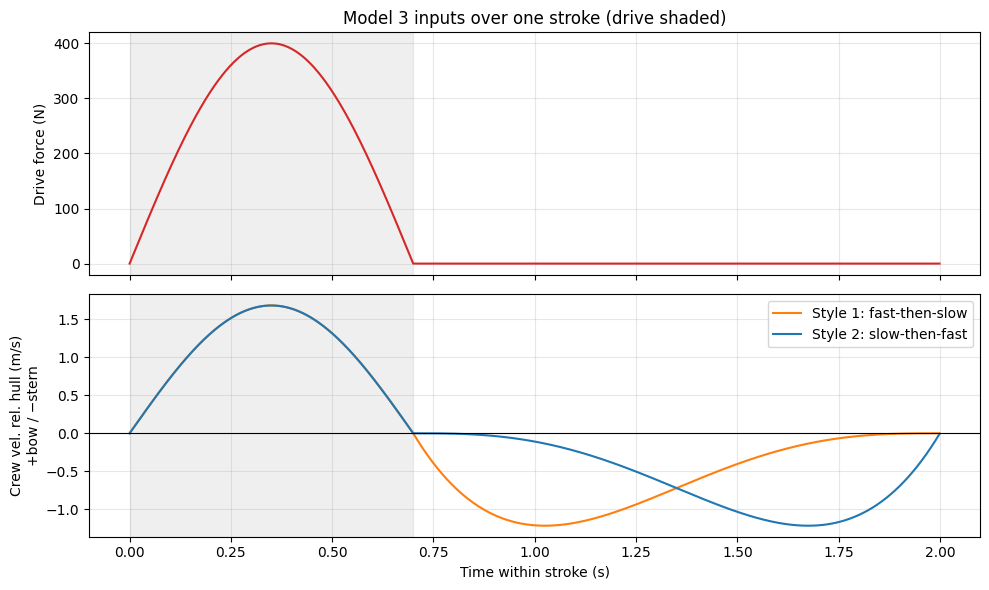

Style 1: drive +0.750 m, recovery -0.750 m
Style 2: drive +0.750 m, recovery -0.750 m


In [1]:
# ============================================================
# Model 3: two-body (hull + crew), drag acts on HULL velocity.
# Question: at fixed impulse, rate, and slide length, does the
# SHAPE of the recovery (style 1 vs style 2) change mean speed?
# Convention: positive = bow (forward). Crew slides bowward in
# the drive (u>0), sternward in recovery (u<0).
# NOTE: this first version brings the crew to rest at the catch
# for BOTH styles — i.e. it deliberately EXCLUDES the catch-check.
# We add the check next, once the pure recovery effect is clear.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt

# --- Masses (Dudhia: crew ~80% of total) ---
m_crew  = 80.0
m_hull  = 20.0
M_total = m_crew + m_hull
mass_ratio = m_crew / M_total      # 0.8 — the coupling strength

# --- Drive force, timing, drag (same lineage as Models 1-2) ---
F_max      = 400.0
t_drive    = 0.7
t_recovery = 1.3
t_stroke   = t_drive + t_recovery
dt         = 0.001
n_strokes  = 20
a_drag     = 3.0                   # validated single-sculler value
L_slide    = 0.75                  # crew travel relative to hull, m

# --- Build templates over ONE stroke ---
t_one = np.arange(0, t_stroke, dt)

# Drive force: sine pulse in the drive, zero in recovery
F_template = np.where(t_one < t_drive,
                      F_max * np.sin(np.pi * t_one / t_drive), 0.0)

def crew_velocity_template(p, q):
    """Crew velocity relative to hull over one stroke.
    Drive = bowward half-sine (+L_slide). Recovery = sternward
    hump skewed by (p,q), normalised to exactly -L_slide."""
    u = np.zeros_like(t_one)
    drive = t_one < t_drive
    rec   = ~drive

    ds = np.sin(np.pi * t_one[drive] / t_drive)
    u[drive] = (L_slide / (ds.sum() * dt)) * ds          # +L_slide

    x  = (t_one[rec] - t_drive) / t_recovery             # 0..1
    rs = x**(p-1) * (1 - x)**(q-1)                        # skew shape
    u[rec] = -(L_slide / (rs.sum() * dt)) * rs           # -L_slide
    return u

# The TWO styles differ ONLY in recovery shape:
u_style1 = crew_velocity_template(2, 4)   # front-loaded: fast-then-slow
u_style2 = crew_velocity_template(4, 2)   # back-loaded:  slow-then-fast

# --- Verify inputs BEFORE simulating ---
fig, (axF, axU) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axF.plot(t_one, F_template, color="tab:red")
axF.axvspan(0, t_drive, color="grey", alpha=0.12)
axF.set_ylabel("Drive force (N)"); axF.grid(True, alpha=0.3)
axF.set_title("Model 3 inputs over one stroke (drive shaded)")

axU.plot(t_one, u_style1, color="tab:orange", label="Style 1: fast-then-slow")
axU.plot(t_one, u_style2, color="tab:blue",   label="Style 2: slow-then-fast")
axU.axhline(0, color="black", lw=0.8)
axU.axvspan(0, t_drive, color="grey", alpha=0.12)
axU.set_ylabel("Crew vel. rel. hull (m/s)\n+bow / −stern")
axU.set_xlabel("Time within stroke (s)")
axU.legend(loc="upper right"); axU.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Sanity: both styles must move the SAME slide length each phase
for name, u in [("Style 1", u_style1), ("Style 2", u_style2)]:
    print(f"{name}: drive {(u[t_one<t_drive].sum()*dt):+.3f} m, "
          f"recovery {(u[t_one>=t_drive].sum()*dt):+.3f} m")

In [2]:
# --- Cell 2: two-body engine. Drag acts on the HULL. ---
def simulate(u_template, n_strokes=n_strokes):
    """Run the two-body model for a given recovery style.
    Returns time, hull velocity, and COM velocity arrays."""
    # Tile the one-stroke templates out to n_strokes
    F = np.tile(F_template, n_strokes)
    u = np.tile(u_template, n_strokes)
    times = np.arange(0, len(F)) * dt

    v_cm   = 0.0                      # centre-of-mass velocity
    v_hull = np.zeros_like(times)     # what drag actually sees
    v_com  = np.zeros_like(times)

    for i in range(len(times)):
        # Hull velocity from momentum coupling (the heart of it):
        vh = v_cm - mass_ratio * u[i]

        # Drag acts on the HULL speed, not the COM:
        drag = -a_drag * vh * abs(vh)

        # External forces (drive + drag) move the WHOLE system COM:
        net = F[i] + drag
        v_cm = v_cm + (net / M_total) * dt

        v_hull[i] = vh
        v_com[i]  = v_cm
    return times, v_hull, v_com

# Run both styles
t1, vh1, vc1 = simulate(u_style1)
t2, vh2, vc2 = simulate(u_style2)

# Compare mean HULL speed over the final stroke (steady state)
last = slice(-len(t_one), None)
mean1 = vh1[last].mean()
mean2 = vh2[last].mean()

print(f"Style 1 (fast-then-slow): mean hull speed = {mean1:.4f} m/s")
print(f"Style 2 (slow-then-fast): mean hull speed = {mean2:.4f} m/s")
print(f"Difference: {(mean2-mean1):+.4f} m/s "
      f"({100*(mean2-mean1)/mean1:+.2f}%)")

Style 1 (fast-then-slow): mean hull speed = 5.3779 m/s
Style 2 (slow-then-fast): mean hull speed = 5.3987 m/s
Difference: +0.0208 m/s (+0.39%)


In [3]:
# --- Cell 3: convert steady-state speed into a 700m course result ---
distance_home = 700.0   # your home course, metres

def course_time(mean_speed, distance):
    return distance / mean_speed

t1_home = course_time(mean1, distance_home)
t2_home = course_time(mean2, distance_home)
gap_home = t1_home - t2_home          # +ve => style 2 finishes first

# A boat length for a single scull ~ 8.2 m; gap in lengths = gap_dist / 8.2
boat_length = 8.2
gap_distance_home = mean2 * gap_home  # how far ahead style 2 is at the line

print(f"Over {distance_home:.0f} m at steady state:")
print(f"  Style 1: {t1_home:.2f} s")
print(f"  Style 2: {t2_home:.2f} s")
print(f"  Style 2 wins by {gap_home:.2f} s "
      f"= {gap_distance_home:.2f} m = {gap_distance_home/boat_length:.2f} boat lengths\n")

# Bonus: how the margin compounds with distance (it scales linearly)
print("Margin to style 2 by distance:")
for d in [500, 700, 1000, 2000]:
    g = d/mean1 - d/mean2
    print(f"  {d:>4d} m : {g:+.2f} s  ({mean2*g/boat_length:+.2f} lengths)")

Over 700 m at steady state:
  Style 1: 130.16 s
  Style 2: 129.66 s
  Style 2 wins by 0.50 s = 2.71 m = 0.33 boat lengths

Margin to style 2 by distance:
   500 m : +0.36 s  (+0.24 lengths)
   700 m : +0.50 s  (+0.33 lengths)
  1000 m : +0.72 s  (+0.47 lengths)
  2000 m : +1.43 s  (+0.94 lengths)


In [4]:
# --- Cell 4: parameterised engine for sensitivity analysis ---
def build_u(p, q, t_drive, t_recovery, L_slide=0.75, dt=0.001):
    """Crew velocity rel. hull over one stroke, given recovery skew (p,q)
    and phase durations. Drive = bowward half-sine; recovery = skewed
    sternward hump. Each phase normalised to exactly +/- L_slide."""
    t_stroke = t_drive + t_recovery
    t_one = np.arange(0, t_stroke, dt)
    u = np.zeros_like(t_one)
    drive = t_one < t_drive
    rec   = ~drive

    ds = np.sin(np.pi * t_one[drive] / t_drive)
    u[drive] = (L_slide / (ds.sum()*dt)) * ds

    x  = (t_one[rec] - t_drive) / t_recovery
    rs = x**(p-1) * (1-x)**(q-1)
    u[rec] = -(L_slide / (rs.sum()*dt)) * rs
    return t_one, u

def build_F(t_drive, t_recovery, F_max=400.0, dt=0.001):
    t_one = np.arange(0, t_drive+t_recovery, dt)
    return np.where(t_one < t_drive,
                    F_max*np.sin(np.pi*t_one/t_drive), 0.0)

def mean_hull_speed(p, q, t_drive, t_recovery, a_drag,
                    m_crew=80.0, m_hull=20.0, n_strokes=25, dt=0.001):
    """Run to steady state, return mean hull speed over the final stroke."""
    M = m_crew + m_hull
    ratio = m_crew / M
    _, u_one = build_u(p, q, t_drive, t_recovery, dt=dt)
    F_one    = build_F(t_drive, t_recovery, dt=dt)
    F = np.tile(F_one, n_strokes)
    u = np.tile(u_one, n_strokes)

    v_cm = 0.0
    vhull = np.zeros(len(F))
    for i in range(len(F)):
        vh = v_cm - ratio*u[i]
        drag = -a_drag * vh*abs(vh)
        v_cm += ((F[i]+drag)/M)*dt
        vhull[i] = vh
    return vhull[-len(F_one):].mean()

# Quick check it reproduces Model 3's baseline:
base1 = mean_hull_speed(2, 4, 0.7, 1.3, 3.0)   # style 1
base2 = mean_hull_speed(4, 2, 0.7, 1.3, 3.0)   # style 2
print(f"Baseline check — style 1: {base1:.4f}, style 2: {base2:.4f}, "
      f"diff {100*(base2-base1)/base1:+.2f}%")

Baseline check — style 1: 5.3780, style 2: 5.3987, diff +0.39%


In [5]:
# --- Cell 5a: sensitivity analysis — skew strength and stroke rate ---
# We compare a "style 1" (front-loaded) against its mirror "style 2"
# (back-loaded) across (a) how asymmetric the recovery is, and
# (b) stroke rate (via recovery duration). Positive % => style 2 faster.

print("SKEW STRENGTH  (drive 0.7s, recovery 1.3s, drag 3.0)")
print("  mild -> strong asymmetry; (p,q) vs mirror (q,p)\n")
for p, q in [(2.5, 3.5), (2.0, 4.0), (1.5, 4.5), (1.3, 5.0)]:
    s1 = mean_hull_speed(p, q, 0.7, 1.3, 3.0)   # front-loaded
    s2 = mean_hull_speed(q, p, 0.7, 1.3, 3.0)   # back-loaded (mirror)
    print(f"  skew ({p},{q}): style1 {s1:.4f}  style2 {s2:.4f}  "
          f"diff {100*(s2-s1)/s1:+.2f}%")

print("\nSTROKE RATE  (skew 2/4 vs 4/2, drag 3.0)")
print("  lower rate = longer recovery; rate ~ 60/stroke_period\n")
for t_d, t_r in [(0.8, 1.8), (0.7, 1.3), (0.6, 1.0), (0.5, 0.7)]:
    rate = 60.0 / (t_d + t_r)
    s1 = mean_hull_speed(2, 4, t_d, t_r, 3.0)
    s2 = mean_hull_speed(4, 2, t_d, t_r, 3.0)
    print(f"  rate {rate:4.1f}/min: style1 {s1:.4f}  style2 {s2:.4f}  "
          f"diff {100*(s2-s1)/s1:+.2f}%")

SKEW STRENGTH  (drive 0.7s, recovery 1.3s, drag 3.0)
  mild -> strong asymmetry; (p,q) vs mirror (q,p)

  skew (2.5,3.5): style1 5.3847  style2 5.3951  diff +0.19%
  skew (2.0,4.0): style1 5.3780  style2 5.3987  diff +0.39%
  skew (1.5,4.5): style1 5.3690  style2 5.4001  diff +0.58%
  skew (1.3,5.0): style1 5.3621  style2 5.3985  diff +0.68%

STROKE RATE  (skew 2/4 vs 4/2, drag 3.0)
  lower rate = longer recovery; rate ~ 60/stroke_period

  rate 23.1/min: style1 5.0479  style2 5.0686  diff +0.41%
  rate 30.0/min: style1 5.3780  style2 5.3987  diff +0.39%
  rate 37.5/min: style1 5.5499  style2 5.5705  diff +0.37%
  rate 50.0/min: style1 5.8109  style2 5.8310  diff +0.35%


In [6]:
# --- Cell 5b: sensitivity to drag coefficient ---
# Mechanism prediction: at a_drag -> 0, the style difference must
# VANISH (Model 1's lesson: no drag, only impulse matters).
# Higher drag should amplify it. This tests the mechanism itself.

print("DRAG COEFFICIENT  (skew 2/4 vs 4/2, drive 0.7s, recovery 1.3s)\n")
for a in [0.1, 1.0, 3.0, 6.0, 10.0]:
    s1 = mean_hull_speed(2, 4, 0.7, 1.3, a)
    s2 = mean_hull_speed(4, 2, 0.7, 1.3, a)
    print(f"  drag {a:4.1f}: style1 {s1:.4f}  style2 {s2:.4f}  "
          f"diff {100*(s2-s1)/s1:+.3f}%  (abs {s2-s1:+.4f} m/s)")

DRAG COEFFICIENT  (skew 2/4 vs 4/2, drive 0.7s, recovery 1.3s)

  drag  0.1: style1 26.9079  style2 26.9125  diff +0.017%  (abs +0.0046 m/s)
  drag  1.0: style1 9.3969  style2 9.4091  diff +0.130%  (abs +0.0122 m/s)
  drag  3.0: style1 5.3780  style2 5.3987  diff +0.387%  (abs +0.0208 m/s)
  drag  6.0: style1 3.7522  style2 3.7810  diff +0.766%  (abs +0.0288 m/s)
  drag 10.0: style1 2.8550  style2 2.8911  diff +1.263%  (abs +0.0361 m/s)


                         Style 1 (front)   Style 2 (back)
  mean hull speed (m/s)       5.3779         5.3987
  variance of hull speed     0.78648        0.56245
  mean of v^2 (drag ~)       29.7086        29.7086

  Style 2 has HIGHER mean-of-v^2 -> more drag loss
  Style 2 min speed: 3.887 vs Style 1 min: 3.911  (the catch trough)
  Style 2 max speed: 6.066 vs Style 1 max: 6.706  (the peak)


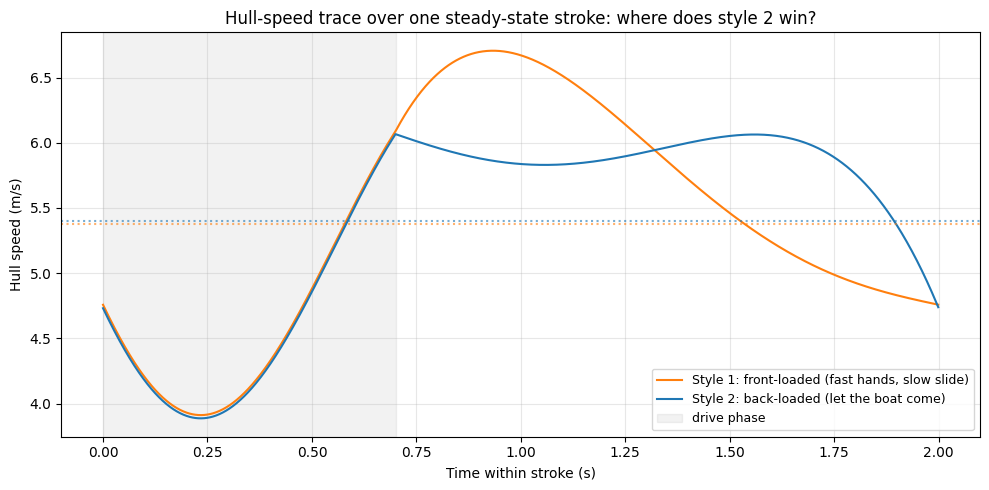

In [7]:
# --- Diagnostic: WHY is style 2 faster? Compare the hull-speed traces ---
# We extract one steady-state stroke from each style and compare:
#   (a) the shape of the hull-speed trace (variance vs "time near peak")
#   (b) mean speed, variance, and mean-of-v^2 (what actually sets drag loss)

t1, vh1, vc1 = simulate(u_style1)   # front-loaded (style 1)
t2, vh2, vc2 = simulate(u_style2)   # back-loaded  (style 2)

# Take the final (steady-state) stroke from each
n_one = len(t_one)
s1 = vh1[-n_one:]          # style 1 hull speed over last stroke
s2 = vh2[-n_one:]          # style 2 hull speed over last stroke
tt = np.arange(n_one) * dt # time within the stroke

# The three numbers that decide the mechanism
def stats(v):
    return v.mean(), v.var(), (v**2).mean()   # mean, variance, mean-of-v^2

m1, var1, msq1 = stats(s1)
m2, var2, msq2 = stats(s2)

print("                         Style 1 (front)   Style 2 (back)")
print(f"  mean hull speed (m/s)   {m1:10.4f}     {m2:10.4f}")
print(f"  variance of hull speed  {var1:10.5f}     {var2:10.5f}")
print(f"  mean of v^2 (drag ~)    {msq1:10.4f}     {msq2:10.4f}")
print(f"\n  Style 2 has {'LOWER' if msq2 < msq1 else 'HIGHER'} mean-of-v^2 "
      f"-> {'less' if msq2 < msq1 else 'more'} drag loss")
print(f"  Style 2 min speed: {s2.min():.3f} vs Style 1 min: {s1.min():.3f}  (the catch trough)")
print(f"  Style 2 max speed: {s2.max():.3f} vs Style 1 max: {s1.max():.3f}  (the peak)")

# The picture that settles it
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tt, s1, color="tab:orange", label="Style 1: front-loaded (fast hands, slow slide)")
ax.plot(tt, s2, color="tab:blue",   label="Style 2: back-loaded (let the boat come)")
ax.axhline(m1, color="tab:orange", ls=":", alpha=0.6)
ax.axhline(m2, color="tab:blue",   ls=":", alpha=0.6)
ax.axvspan(0, t_drive, color="grey", alpha=0.10, label="drive phase")
ax.set_xlabel("Time within stroke (s)")
ax.set_ylabel("Hull speed (m/s)")
ax.set_title("Hull-speed trace over one steady-state stroke: where does style 2 win?")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# --- Confirm the mechanism: drag loss is set by v^3 (power) and v^2|v| (force) ---
# If style 2 is faster BECAUSE it suppresses the peak, it should show the
# LOWER mean-of-v^3 and mean-of-v^2|v|, even though mean-of-v^2 tied.

def drag_metrics(v):
    return (v**2).mean(), (v**3).mean(), (v**2 * np.abs(v)).mean()

sq1, cu1, fi1 = drag_metrics(s1)
sq2, cu2, fi2 = drag_metrics(s2)

print("                          Style 1 (front)   Style 2 (back)")
print(f"  mean of v^2               {sq1:11.4f}    {sq2:11.4f}   (tied -> not the driver)")
print(f"  mean of v^3 (power ~)     {cu1:11.4f}    {cu2:11.4f}")
print(f"  mean of v^2|v| (drag F ~) {fi1:11.4f}    {fi2:11.4f}")
print(f"\n  Style 2 mean-of-v^3 is {'LOWER' if cu2 < cu1 else 'HIGHER'} "
      f"by {100*(cu1-cu2)/cu1:+.2f}%  -> {'less' if cu2<cu1 else 'more'} energy lost to drag")
print(f"  Peak gap: style1 {s1.max():.3f} vs style2 {s2.max():.3f} "
      f"(diff {s1.max()-s2.max():.3f} m/s)")
print(f"  Trough gap: style1 {s1.min():.3f} vs style2 {s2.min():.3f} "
      f"(diff {s1.min()-s2.min():.3f} m/s)")

                          Style 1 (front)   Style 2 (back)
  mean of v^2                   29.7086        29.7086   (tied -> not the driver)
  mean of v^3 (power ~)        168.2070       166.0627
  mean of v^2|v| (drag F ~)    168.2070       166.0627

  Style 2 mean-of-v^3 is LOWER by +1.27%  -> less energy lost to drag
  Peak gap: style1 6.706 vs style2 6.066 (diff 0.640 m/s)
  Trough gap: style1 3.911 vs style2 3.887 (diff 0.025 m/s)
